# Header

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cmdstanpy
import arviz as az

In [2]:
n_chains = 2
iter_warmup = 300
iter_sampling = 300

In [3]:
import boto3
from configparser import ConfigParser
import awswrangler as wr

config = ConfigParser()
config.read(r'C:\Users\RyanKarel\.aws\credentials')

boto3_session = boto3.session.Session(
    aws_access_key_id=config['218527194748_ActuaryAccessProd']['aws_access_key_id'],
    aws_secret_access_key=config['218527194748_ActuaryAccessProd']['aws_secret_access_key'],
    aws_session_token=config['218527194748_ActuaryAccessProd']['aws_session_token'],
    region_name='us-east-1',
)

def query_athena(
    sql: str,
    boto3_session,
    database: str = "rn_actuary_db",
    workgroup: str = "Actuary",
    index_col = None,
    check_index_uniqueness: bool = True,
    force_index_uniqueness: bool = False,
) -> pd.DataFrame:
    output = wr.athena.read_sql_query(
        sql=sql,
        database=database,
        boto3_session=boto3_session,
        workgroup=workgroup,
        ctas_approach=False,
    )
    if index_col is not None:
        if force_index_uniqueness:
            output.drop_duplicates(subset=index_col, inplace=True)
        output.set_index(index_col, inplace=True)
        if check_index_uniqueness:
            assert output.index.is_unique
    return output

# Data Prep

In [4]:
data = query_athena(
    """
with claims_detail as (
    select
        p.num_policy,
        c.num_claim,
        1 as count_claim,
        case when cd_claim_status = 'Closed' then 1 else 0 end as count_closed_claim
    from tbl_claim c
    inner join tbl_policy p
        on c.num_policy = p.num_policy
    where
        not (cd_claim_status = 'Closed' and c.amt_total_incurred <= 1) -- excluding CNPs
        and coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
),

policy_level_claims as (
    select
        num_policy,
        sum(count_claim) as count_claim,
        sum(count_closed_claim) as count_closed_claim
    from claims_detail
    group by 1
),

exposures as (
    select
        num_policy,
        coalesce(
            case
                when cd_exposure_type_group in ('Employees', 'Students', 'Population', 'Children', 'Participants', 'People') then 'People'
                when cd_exposure_type_group in ('Class A', 'Class B', 'Class C', 'Class D') then 'Class A-D'
                else cd_exposure_type_group
                end,
            'Unknown'
        ) as cd_exposure_type_group,
        sum(try_cast(amt_exposure as bigint)) as amt_exposure
    from tbl_exposure
    group by 1, 2
),

exposures_at_policy_grain as (
    select
        num_policy,
        map_agg(cd_exposure_type_group, amt_exposure) as map_exposure_profile
    from exposures
    group by 1
)

select
    num_policy,
    dt_policy_effective,
    coalesce(dt_cancellation, dt_policy_expiration) as dt_policy_expiration,
    date_diff('day', dt_policy_effective, current_timestamp) / 365.0 as age_since_effective,
    date_diff('day', coalesce(dt_cancellation, dt_policy_expiration), current_timestamp) / 365.0 as age_since_expiration,
    p.cd_coverage_form,
    case when p.cd_coverage_form = 'Occurrence' then 1 else 0 end as ind_occurrence_form,
    lc.cd_largest_class,
    coalesce(lcg.cd_group_name, 'Other') as cd_largest_class_group,
    cd_primary_risk_state,

    map_exposure_profile['Units'] as amt_units,
    map_exposure_profile['Sales'] as amt_sales,
    map_exposure_profile['Payroll'] as amt_payroll,
    map_exposure_profile['Beds'] as amt_beds,
    map_exposure_profile['Square Feet'] as amt_square_feet,
    map_exposure_profile['Cost'] as amt_cost,
    map_exposure_profile['People'] as amt_people,
    map_exposure_profile['Class A-D'] as amt_class_a_d,
    map_exposure_profile['Acres'] as amt_acres,
    map_exposure_profile['Gallons'] as amt_gallons,

    p.cd_product,
    p.num_policy_term_length / 365.0 as amt_term_factor,

    coalesce(c.count_claim, 0) as count_claim
from tbl_policy p
left join tbl_largest_class lc using (num_policy)
left join vw_largest_class_group lcg using (num_policy)
left join exposures_at_policy_grain e using (num_policy)
left join policy_level_claims c using (num_policy)
where
    coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
    and p.cd_product not in ('CP', 'IM') -- non property
    """,
    boto3_session=boto3_session
)
data = data.loc[data.loc[:, 'amt_units':'amt_gallons'].fillna(0).sum(axis=1) > 0]
data = data.loc[data.loc[:, 'amt_term_factor'].fillna(0) > 0]
data = data.loc[data.loc[:, 'dt_policy_expiration'] < pd.Timestamp('now').date()]
data.set_index('num_policy', inplace=True)
data['idx_policy'] = np.arange(1, len(data) + 1)
data

,dt_policy_effective,dt_policy_expiration,age_since_effective,age_since_expiration,cd_coverage_form,ind_occurrence_form,cd_largest_class,cd_largest_class_group,cd_primary_risk_state,amt_units,...,amt_square_feet,amt_cost,amt_people,amt_class_a_d,amt_acres,amt_gallons,cd_product,amt_term_factor,count_claim,idx_policy
num_policy,,,,,,,,,,,,,,,,,,,,,
RN-7-0324092,2022-01-04,2023-01-04,4.660274,3.660274,Claims Made and Reported,0,<NA>,Insurance Agents,FL,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,PL,1.0,0,1
RN-7-0324234,2022-05-17,2023-05-17,4.295890,3.295890,Occurrence,1,91580,Other Contracting,CA,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CN,1.0,0,2
RN-7-0324264,2022-05-31,2023-05-31,4.257534,3.257534,Occurrence,1,62003,Condominiums,FL,183,...,55500,<NA>,<NA>,<NA>,<NA>,<NA>,GC,1.0,0,3
RN-7-0324294,2022-06-12,2023-06-12,4.224658,3.224658,Occurrence,1,62003,Condominiums,FL,136,...,48600,<NA>,<NA>,<NA>,<NA>,<NA>,GC,1.0,0,4
RN-7-0324313,2022-07-01,2023-07-01,4.172603,3.172603,Claims Made and Reported,0,<NA>,School Boards,IL,<NA>,...,<NA>,<NA>,1879,<NA>,<NA>,<NA>,PE,1.0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RN-7-0511877,2025-06-07,2026-06-07,1.235616,0.235616,Occurrence,1,60011,Apartments,CA,38,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,SGC,1.0,0,12307
RN-7-0512329,2025-07-01,2026-07-01,1.169863,0.169863,Occurrence,1,91580,Other Contracting,CA,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,SCN,1.0,0,12308
RN-7-0513184,2025-08-19,2026-08-19,1.035616,0.035616,Occurrence,1,91342,Carpentry,WA,<NA>,...,<NA>,5000000,<NA>,<NA>,<NA>,<NA>,CN,1.0,0,12309


In [5]:
claims = query_athena("""
    with incurred_date_selection as (
        select
            num_claim,
            num_policy,
            1 as count_claim,
            if(
                p.cd_coverage_form = 'Occurrence',
                dt_claim_occurrence,
                coalesce(
                    -- ensuring claim made to insured on or before RNIC report date
                    case when dt_claim_made_to_insured < dt_claim_report then dt_claim_made_to_insured end,
                    dt_claim_report
                )
            ) as dt_claim_incurred,
            dt_claim_report
        from tbl_claim c
        inner join tbl_policy p using (num_policy)
        where
            not (cd_claim_status = 'Closed' and c.amt_total_incurred <= 1) -- excluding CNPs
            and coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
            and p.cd_product not in ('CP', 'IM') -- non property
    )
    select
        num_policy,
        num_claim,
        count_claim,
        date_diff(
            'day',
            dt_claim_incurred,
            dt_claim_report
        ) / 365.0 as amt_report_lag
    from incurred_date_selection c
    inner join tbl_policy p using (num_policy)
    where
        dt_claim_incurred >= dt_policy_effective
    """,
    boto3_session=boto3_session
)
claims = claims.merge(data[['idx_policy', 'age_since_effective']], how='inner', left_on='num_policy', right_index=True)
claims

,num_policy,num_claim,count_claim,amt_report_lag,idx_policy,age_since_effective
0,RN-7-0328087,RN-9-0002143,1,0.008219,9747,2.169863
1,RN-7-0501467,RN-9-0002163,1,1.057534,8532,3.002740
2,RN-7-0326748-01,RN-9-0002188,1,0.000000,5921,2.169863
3,RN-7-0506263,RN-9-0002209,1,0.054795,10442,2.093151
4,RN-7-0327639-01,RN-9-0002234,1,0.000000,1713,1.569863
...,...,...,...,...,...,...
1805,RN-7-0511306,RN-9-0004249,1,1.298630,8445,1.320548
1809,RN-7-0511618,RN-9-0004260,1,0.556164,10945,1.298630
1810,RN-7-0504745-01,RN-9-0004267,1,1.000000,3750,1.380822
1812,RN-7-0327530,RN-9-90001209,1,0.219178,8919,2.668493


In [6]:
# exposure expressed on annualized basis, so this is how we get just the earned portion for expired policies
exposure = data.loc[:, 'amt_units':'amt_gallons'].fillna(0).mul(data.loc[:, 'amt_term_factor'], axis=0)
class_code = data.loc[:, 'cd_largest_class_group'].astype('category')
risk_state = data.loc[:, 'cd_primary_risk_state'].astype('category')
product = data.loc[:, 'cd_product'].replace({'SGC': 'GC', 'SCN': 'CN'}).astype('category')
frequency = data.loc[:, 'count_claim'] # reported basis
term_length = data.loc[:, 'amt_term_factor'] # reported basis
policy_age = data.loc[:, 'age_since_effective'] # reported basis
ind_occurrence = data.loc[:, 'ind_occurrence_form']
pd.concat([ind_occurrence, product], axis=1).value_counts().sort_index()

ind_occurrence_form  cd_product
0                    AH            1587
                     CN               0
                     GC               0
                     ML             109
                     PE             335
                     PL            1583
                     PR              95
1                    AH              43
                     CN            4366
                     GC            3623
                     ML               0
                     PE              88
                     PL               0
                     PR             482
Name: count, dtype: int64

In [7]:
# scale exposure by the avg amongst records that have non-zero values
exposure_avg_scale = pd.Series(index=exposure.columns)
for col in exposure:
    exposure_avg_scale.loc[col] = exposure.query(f"{col} > 0")[col].mean()
scaled_exposure = exposure / exposure_avg_scale
scaled_exposure.describe()

,amt_units,amt_sales,amt_payroll,amt_beds,amt_square_feet,amt_cost,amt_people,amt_class_a_d,amt_acres,amt_gallons
count,12311.0,12311.0,12311.0,12311.0,12311.0,12311.0,12311.0,12311.0,12311.0,12311.0
mean,0.237917,0.355211,0.236374,0.110227,0.219316,0.171229,0.080335,0.007148,0.006336,0.001868
std,0.941377,1.358891,0.902041,0.617768,1.266657,0.937294,2.023423,0.144568,0.688181,0.063154
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.247565,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,26.043187,49.648574,52.169556,22.684214,43.201896,36.860304,105.692312,5.932275,76.355158,4.394442


In [8]:
observed_data = (
    data[['idx_policy']]
    .reset_index()
    .merge(
        (
            claims
            .groupby('idx_policy')
            .size()
            .rename('reported_claims')
        ),
        how='left',
        on='idx_policy'
    )
    .set_index('num_policy')
    .loc[data.index]
    ['reported_claims']
    .fillna(0)
    .astype(int)
)
observed_data.value_counts().sort_index()

reported_claims
0     11303
1       780
2       139
3        42
4        20
5        12
6         5
7         2
9         2
10        1
11        1
13        1
14        2
25        1
Name: count, dtype: int64

## EDA

In [9]:
np.log((claims['amt_report_lag'] == 0).mean())

np.float64(-1.8657107875081895)

count    1245.000000
mean        0.476019
std         0.640694
min         0.002740
25%         0.043836
50%         0.178082
75%         0.654795
max         3.419178
Name: amt_report_lag, dtype: float64

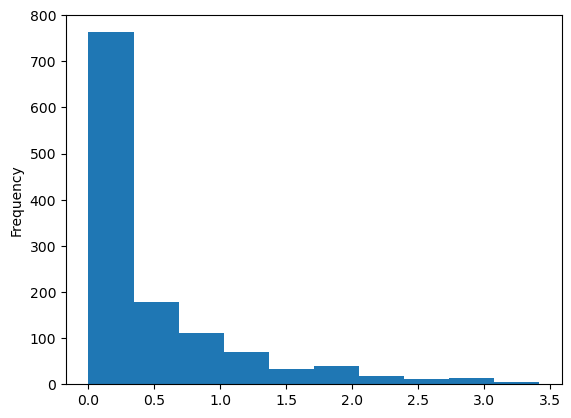

In [10]:
claims.query("amt_report_lag > 0")['amt_report_lag'].plot(kind='hist')
claims.query("amt_report_lag > 0")['amt_report_lag'].describe()
# plt.xscale('log')
# claims.groupby(['amt_report_lag'].describe()

# Model

## 2-Step: Isolated $R$, then $C$ 

### $R$, Report Lag

#### WINNER: $R$, Report Lag, Cross-Classified

In [11]:
isolated_r_model = cmdstanpy.CmdStanModel(stan_file='frequency__report_lag_R__isolated__cross_classified.stan')

In [12]:
N, E_cols = scaled_exposure.shape
idx_class_code = class_code.cat.codes + 1
idx_risk_state = risk_state.cat.codes + 1
idx_rn_product = product.cat.codes + 1
K_class = idx_class_code.max()
K_state = idx_risk_state.max()
K_rnlob = idx_rn_product.max()
stan_data = {
    # policy related fields
    'N': N,
    'E_cols': E_cols,
    'K_class': K_class,
    'K_state': K_state,
    'K_rnlob': K_rnlob,
    'E': scaled_exposure,
    't': term_length,
    'policy_age': policy_age,
    'g_class': idx_class_code,
    'g_state': idx_risk_state,
    'g_rnlob': idx_rn_product,
    'ind_occurrence': ind_occurrence,

    # claims related fields
    'N_claims': len(claims),
    'idx_policy': claims['idx_policy'],
    'R': claims['amt_report_lag'],

    'prior_only': 0
}

noise_scale = 10
mcmc_inits = {
    'R_log_shape_mu': 0.0,
    'R_log_scale_mu': -2.0,
    'R_p0_logit_mu': 0.0,
    'R_log_shape_sigma_class': 0.5,
    'R_log_shape_sigma_state': 0.5,
    'R_log_shape_sigma_rnlob': 0.5,
    'R_log_shape_class_z': np.random.standard_normal(K_class) / noise_scale,
    'R_log_shape_state_z': np.random.standard_normal(K_state) / noise_scale,
    'R_log_shape_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
    'R_log_shape_occurrence_delta': -0.2,
    'R_log_scale_sigma_class': 0.5,
    'R_log_scale_sigma_state': 0.5,
    'R_log_scale_sigma_rnlob': 0.5,
    'R_log_scale_class_z': np.random.standard_normal(K_class) / noise_scale,
    'R_log_scale_state_z': np.random.standard_normal(K_state) / noise_scale,
    'R_log_scale_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
    'R_log_scale_occurrence_delta': 0.3,
    'R_p0_logit_sigma_rnlob': 0.5,
    'R_p0_logit_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
    'R_p0_logit_occurrence_delta': 1
}

prior_r = isolated_r_model.sample(
    data={**stan_data, 'prior_only': 1},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

posterior_r = isolated_r_model.sample(
    data={**stan_data, 'prior_only': 0},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

15:10:27 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

15:12:05 - cmdstanpy - INFO - CmdStan done processing.
15:12:05 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: uniform_rng: Upper bound parameter is 0, but must be greater than 0.000000 (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 15, column 8 to column 35) (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 284, column 8 to line 289, column 10)
	Exception: Exception: uniform_rng: Upper bound parameter is 0, but must be greater than 0.000000 (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 15, column 8 to column 35) (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 284, column 8 to line 289, column 10)
Consider re-running with show_console=True if the above output is unclear!


15:12:12 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

15:19:51 - cmdstanpy - INFO - CmdStan done processing.
15:19:51 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 260, column 8 to line 273, column 10)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 260, column 8 to line 273, column 10)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 260, column 8 t

15:19:57 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 2 divergent transitions (0.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


##### Diagnostics

In [105]:
iso_r_idata = az.from_cmdstanpy(
    posterior=posterior_r,
    posterior_predictive='R_post_pred',
    prior=prior_r,
    prior_predictive='R_post_pred',
    observed_data={'R_post_pred': claims['amt_report_lag']},
    log_likelihood={'R_post_pred': 'R_log_lik'}
)

<Axes: ylabel='Frequency'>

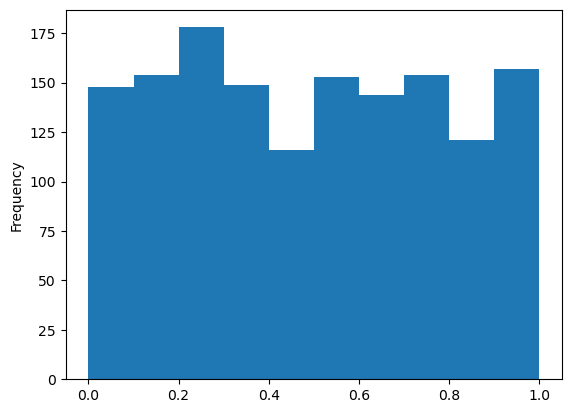

In [106]:
pit_values = pd.Series(az.loo_pit(iso_r_idata)['R_post_pred'].values, index=claims['num_claim'], name='pit')
pit_values.plot(kind='hist')

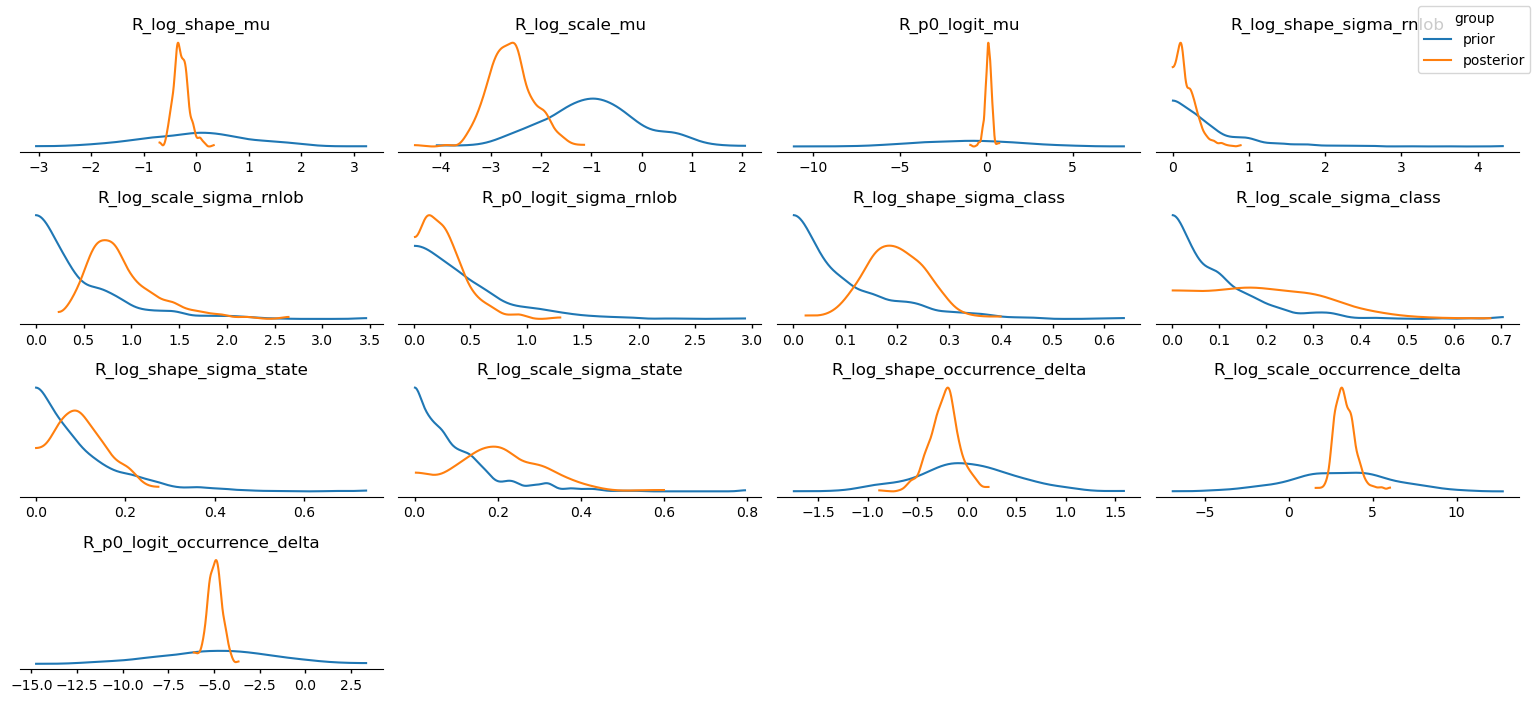

In [110]:
az.plot_prior_posterior(
    iso_r_idata,
    var_names=[
        'R_log_shape_mu',
        'R_log_scale_mu',
        'R_p0_logit_mu',
        'R_log_shape_sigma_rnlob',
        'R_log_scale_sigma_rnlob',
        'R_p0_logit_sigma_rnlob',
        'R_log_shape_sigma_class',
        'R_log_scale_sigma_class',
        'R_log_shape_sigma_state',
        'R_log_scale_sigma_state',
        'R_log_shape_occurrence_delta',
        'R_log_scale_occurrence_delta',
        'R_p0_logit_occurrence_delta',
        # 'R_log_shape_rnlob_z',
        # 'R_log_scale_rnlob_z',
        # 'R_p0_logit_rnlob_z'
    ]
)
plt.tight_layout()

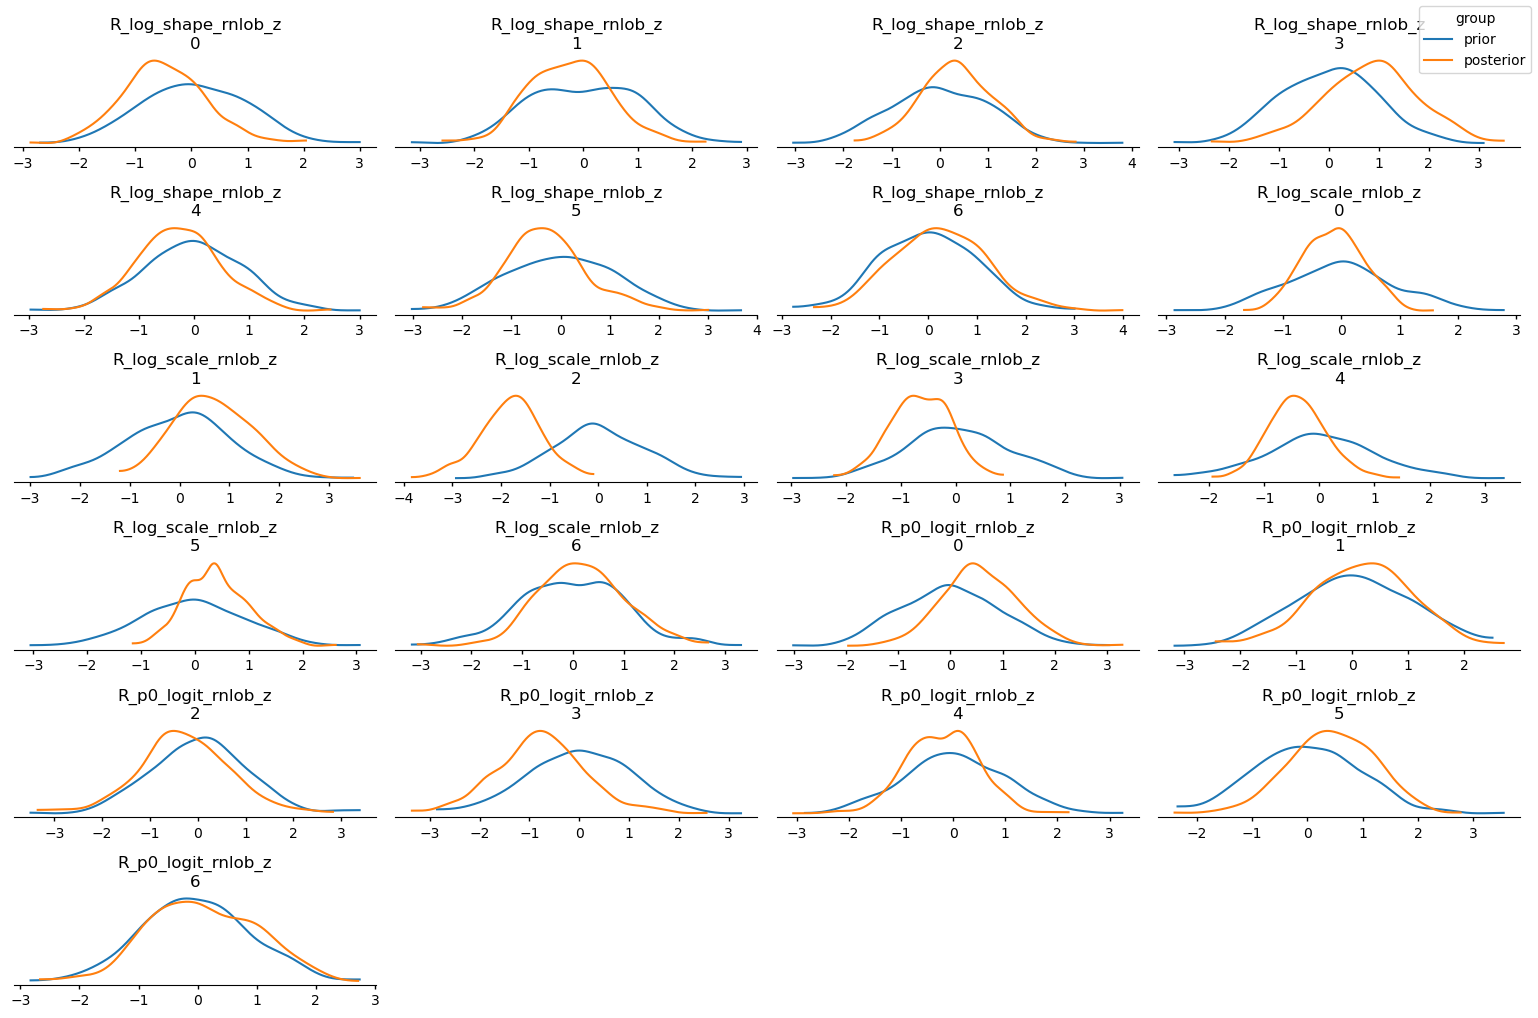

In [111]:
az.plot_prior_posterior(
    iso_r_idata,
    var_names=[
        'R_log_shape_rnlob_z',
        'R_log_scale_rnlob_z',
        'R_p0_logit_rnlob_z'
    ]
)
plt.tight_layout()

#### $R$, Report Lag, Reduced

In [112]:
reduced_r_model = cmdstanpy.CmdStanModel(stan_file='frequency__report_lag_R__isolated__cross_classified__reduced.stan')

12:04:29 - cmdstanpy - INFO - compiling stan file C:\Users\RYANKA~1\AGGREG~1\frequency__report_lag_R__isolated__cross_classified__reduced.stan to exe file C:\Users\RyanKarel\Aggregate Loss Cost Modeling\frequency__report_lag_R__isolated__cross_classified__reduced.exe
12:09:22 - cmdstanpy - INFO - compiled model executable: C:\Users\RyanKarel\Aggregate Loss Cost Modeling\frequency__report_lag_R__isolated__cross_classified__reduced.exe


In [113]:
prior_r_reduced = reduced_r_model.sample(
    data={**stan_data, 'prior_only': 1},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

posterior_r_reduced = reduced_r_model.sample(
    data={**stan_data, 'prior_only': 0},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

12:09:25 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

12:10:28 - cmdstanpy - INFO - CmdStan done processing.
12:10:29 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: uniform_rng: Upper bound parameter is 0, but must be greater than 0.000000 (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 15, column 8 to column 35) (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 254, column 8 to line 259, column 10)
Exception: Exception: uniform_rng: Upper bound parameter is 0, but must be greater than 0.000000 (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 15, column 8 to column 35) (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 254, column 8 to line 259, column 10)
	Exception: Exception: uniform_rng: Upper bound parameter is 0, but must be greater than 0.000000 (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 15, column 8 to column 35) (in 'frequency__report_lag_R__isolated__

12:10:41 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

12:30:58 - cmdstanpy - INFO - CmdStan done processing.
12:30:58 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 230, column 8 to line 243, column 10)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 230, column 8 to line 243, column 10)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified__reduced.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated_

##### Diagnostics

In [114]:
reduced_r_idata = az.from_cmdstanpy(
    posterior=posterior_r_reduced,
    posterior_predictive='R_post_pred',
    prior=prior_r_reduced,
    prior_predictive='R_post_pred',
    observed_data={'R_post_pred': claims['amt_report_lag']},
    log_likelihood={'R_post_pred': 'R_log_lik'}
)

<Axes: ylabel='Frequency'>

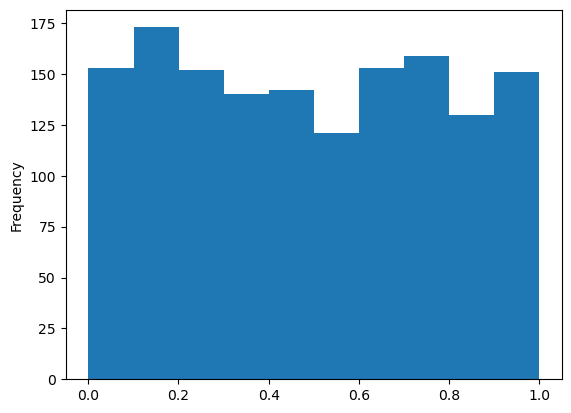

In [115]:
pit_values = pd.Series(az.loo_pit(reduced_r_idata)['R_post_pred'].values, index=claims['num_claim'], name='pit')
pit_values.plot(kind='hist')

#### Compare

In [ ]:
az.compare({
    'iso-d report lag, full': iso_r_idata,
    'reduced report lag': reduced_r_idata
})

c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.64 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd,p,elpd_diff,weight,se,dse,warning
"iso-d report lag, full",0,-200.0,38.5,0.0,1.0,49.0,0.0,True
reduced report lag,1,-220.0,15.9,-19.0,0.0,49.0,4.7,False


The more feavily featured model is the one we're looking for. Let's get the *a posteriori* estimates of $\theta_R$ from it.

count    12311.000000
mean         0.781965
std          0.225708
min          0.107143
25%          0.560040
50%          0.890734
75%          0.997503
max          1.000000
Name: theta_R, dtype: float64

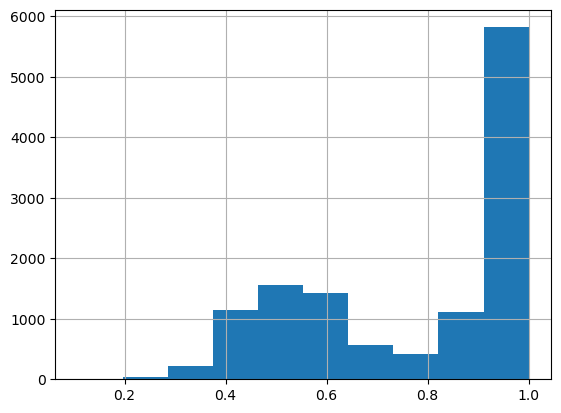

In [13]:
percent_claims_reported = pd.Series(
    posterior_r.stan_variable('theta_R_posterior').mean(axis=0),
    index=data.index,
    name='theta_R'
)
percent_claims_reported.hist()
percent_claims_reported.describe()

### $C$, Claim Frequency

#### WINNER: Cross Classified

In [24]:
freq_cc = cmdstanpy.CmdStanModel(stan_file='frequency__counts_C__cross_classified.stan')

16:38:45 - cmdstanpy - INFO - compiling stan file C:\Users\RYANKA~1\AGGREG~1\frequency__counts_C__cross_classified.stan to exe file C:\Users\RyanKarel\Aggregate Loss Cost Modeling\frequency__counts_C__cross_classified.exe
16:44:17 - cmdstanpy - INFO - compiled model executable: C:\Users\RyanKarel\Aggregate Loss Cost Modeling\frequency__counts_C__cross_classified.exe


In [25]:
stan_data['theta_R'] = percent_claims_reported

noise_scale = 10
mcmc_inits = {
    'log_lambda_0': -5,
    'log_lambda_E': [np.log(0.1)] * E_cols,
    'C_log_phi_mu': 0,
    'C_eta_sigma_class': 0.2,
    'C_eta_sigma_state': 0.2,
    'C_eta_sigma_rnlob': 0.2,
    'C_eta_class_z': np.random.standard_normal(K_class) / noise_scale,
    'C_eta_state_z': np.random.standard_normal(K_state) / noise_scale,
    'C_eta_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
    'C_log_phi_sigma_rnlob': 0.1,
    'C_log_phi_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
}

prior_freq_cc = freq_cc.sample(
    data={**stan_data, 'prior_only': 1},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

posterior_freq_cc = freq_cc.sample(
    data={**stan_data, 'prior_only': 0},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

16:44:19 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

16:47:13 - cmdstanpy - INFO - CmdStan done processing.
16:47:13 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_rng: Random number that came from gamma distribution is 2.02965e+09, but must be less than 1073741824.000000 (in 'frequency__counts_C__cross_classified.stan', line 157, column 4 to column 93)
Exception: neg_binomial_2_log_rng: Random number that came from gamma distribution is 2.60842e+09, but must be less than 1073741824.000000 (in 'frequency__counts_C__cross_classified.stan', line 156, column 4 to column 95)
Consider re-running with show_console=True if the above output is unclear!


16:47:38 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

09:21:01 - cmdstanpy - INFO - CmdStan done processing.
09:21:01 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'frequency__counts_C__cross_classified.stan', line 145, column 8 to column 54)
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'frequency__counts_C__cross_classified.stan', line 145, column 8 to column 54)
Consider re-running with show_console=True if the above output is unclear!


##### Diagnostics

In [26]:
freq_cc_idata = az.from_cmdstanpy(
    posterior=posterior_freq_cc,
    posterior_predictive='C_reported_post_pred',
    prior=prior_freq_cc,
    prior_predictive='C_reported_post_pred',
    observed_data={'C_reported_post_pred': observed_data},
    log_likelihood={'C_reported_post_pred': 'C_reported_log_lik'},
    dtypes={'C_reported_post_pred': 'int'}
)

c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_base\io_cmdstanpy.py:383: RuntimeWarning: invalid value encountered in cast
  raw_draws = raw_draws.astype(dtypes.get(item))


c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_stats\base\diagnostics.py:1275: RuntimeWarning: invalid value encountered in divide
  len_scale = n * (np.log(-b_ary / k_ary) - k_ary - 1)
c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_stats\base\diagnostics.py:1294: RuntimeWarning: invalid value encountered in scalar divide
  sigma = -kappa / b_post


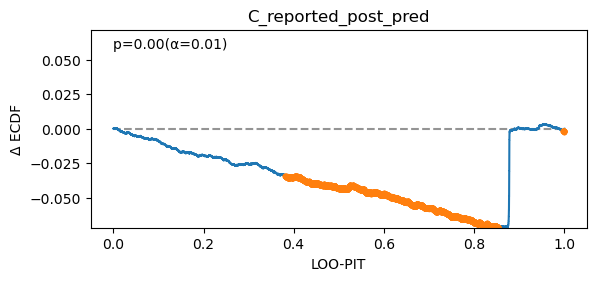

In [27]:
az.plot_loo_pit(freq_cc_idata)

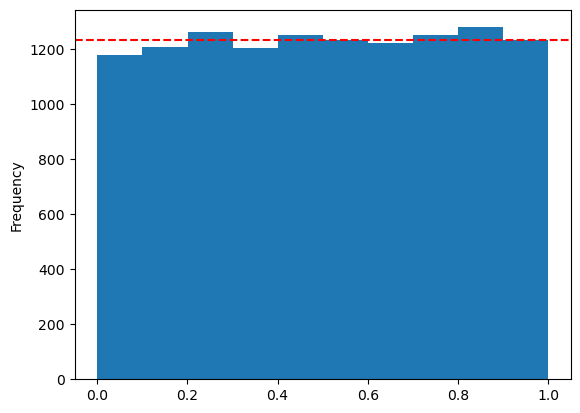

In [28]:
pit_values = pd.Series(az.loo_pit(freq_cc_idata)['C_reported_post_pred'].values, index=data.index, name='pit')
ax = pit_values.plot(kind='hist')
ax.axhline(len(data)/10, color='red', ls='--')

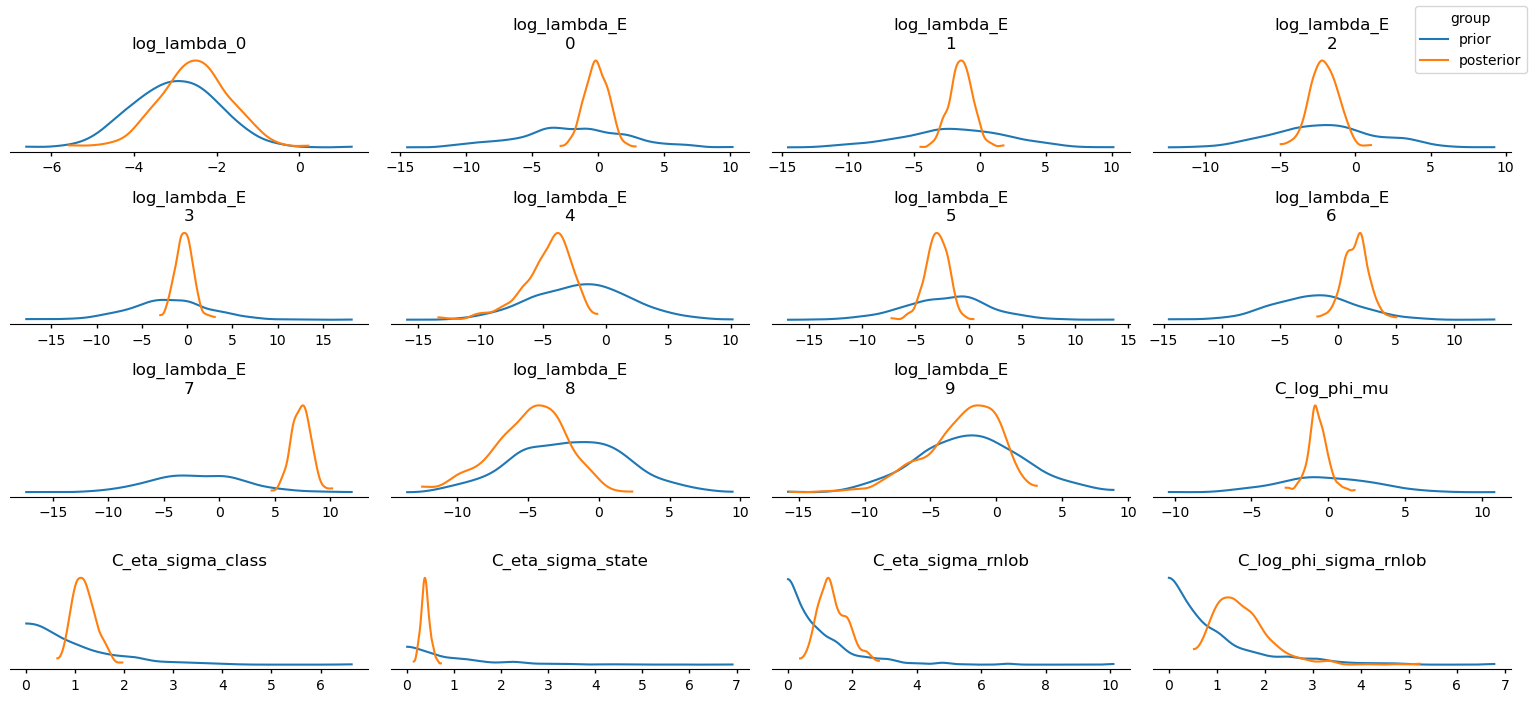

In [29]:
az.plot_prior_posterior(freq_cc_idata, var_names=[
    'log_lambda_0',
    'log_lambda_E',
    'C_log_phi_mu',
    'C_eta_sigma_class',
    'C_eta_sigma_state',
    'C_eta_sigma_rnlob',
    'C_log_phi_sigma_rnlob'
])
plt.tight_layout()

In [30]:
posterior_freq_cc.stan_variable('C_reported_post_pred').mean()

np.float64(0.12298689518858473)

In [31]:
observed_data.mean()

np.float64(0.11964909430590528)

#### Cross Classified, Reduced

In [32]:
freq_cc_reduced = cmdstanpy.CmdStanModel(stan_file='frequency__counts_C__cross_classified__reduced.stan')

09:27:27 - cmdstanpy - INFO - compiling stan file C:\Users\RYANKA~1\AGGREG~1\frequency__counts_C__cross_classified__reduced.stan to exe file C:\Users\RyanKarel\Aggregate Loss Cost Modeling\frequency__counts_C__cross_classified__reduced.exe
09:34:06 - cmdstanpy - INFO - compiled model executable: C:\Users\RyanKarel\Aggregate Loss Cost Modeling\frequency__counts_C__cross_classified__reduced.exe


In [33]:
prior_freq_cc_reduced = freq_cc_reduced.sample(
    data={**stan_data, 'prior_only': 1},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

posterior_freq_cc_reduced = freq_cc_reduced.sample(
    data={**stan_data, 'prior_only': 0},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

09:34:12 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

09:36:35 - cmdstanpy - INFO - CmdStan done processing.


09:36:43 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/600 [00:00<?, ?it/s, (Warmup)]

10:06:52 - cmdstanpy - INFO - CmdStan done processing.
10:06:52 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Precision parameter is 0, but must be positive finite! (in 'frequency__counts_C__cross_classified__reduced.stan', line 146, column 8 to column 54)
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'frequency__counts_C__cross_classified__reduced.stan', line 146, column 8 to column 54)
Consider re-running with show_console=True if the above output is unclear!


##### Diagnostics

In [34]:
freq_cc_reduced_idata = az.from_cmdstanpy(
    posterior=posterior_freq_cc_reduced,
    posterior_predictive='C_reported_post_pred',
    prior=prior_freq_cc_reduced,
    prior_predictive='C_reported_post_pred',
    observed_data={'C_reported_post_pred': observed_data},
    log_likelihood={'C_reported_post_pred': 'C_reported_log_lik'},
    dtypes={'C_reported_post_pred': 'int'}
)

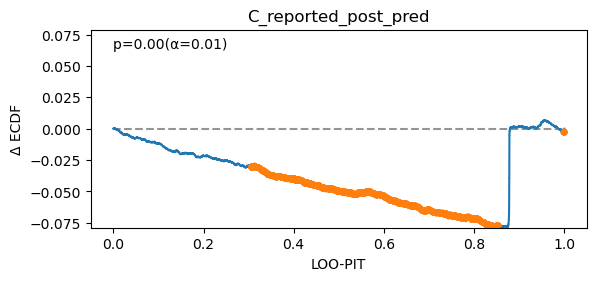

In [37]:
az.plot_loo_pit(freq_cc_reduced_idata)

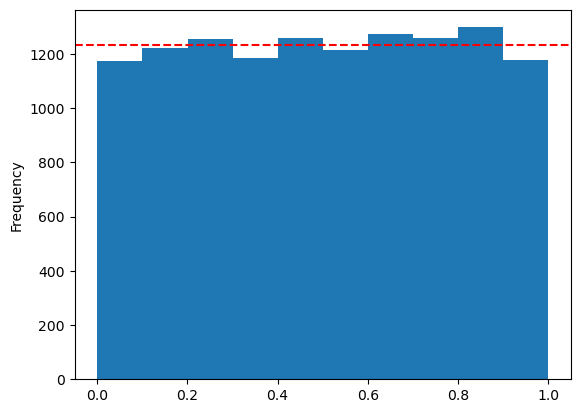

In [38]:
pit_values = pd.Series(az.loo_pit(freq_cc_reduced_idata)['C_reported_post_pred'].values, index=data.index, name='pit')
ax = pit_values.plot(kind='hist')
ax.axhline(len(data)/10, color='red', ls='--')

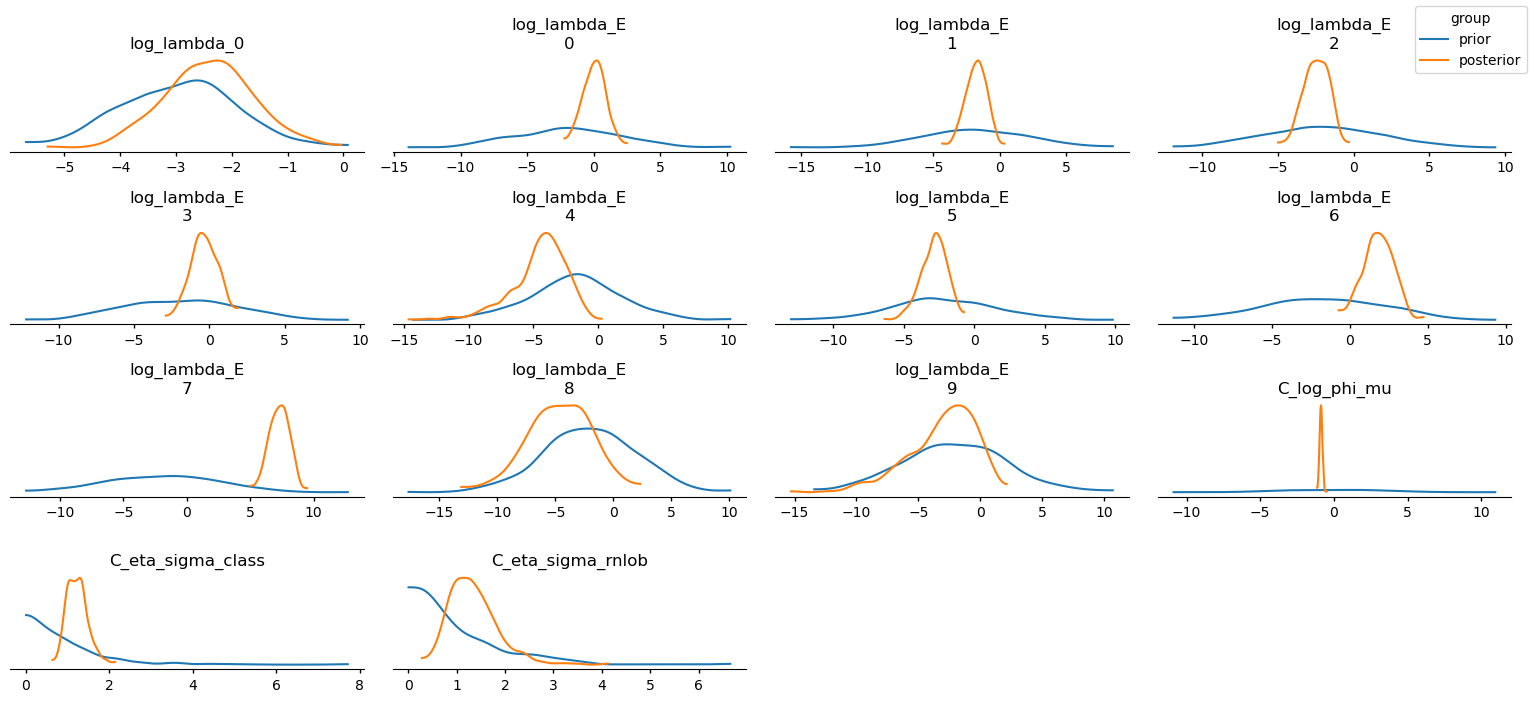

In [40]:
az.plot_prior_posterior(freq_cc_reduced_idata, var_names=[
    'log_lambda_0',
    'log_lambda_E',
    'C_log_phi_mu',
    'C_eta_sigma_class',
    # 'C_eta_sigma_state',
    'C_eta_sigma_rnlob',
    # 'C_log_phi_sigma_rnlob'
])
plt.tight_layout()

In [41]:
posterior_freq_cc_reduced.stan_variable('C_reported_post_pred').mean()

np.float64(0.12739420030866705)

In [42]:
observed_data.mean()

np.float64(0.11964909430590528)

#### Compare

In [43]:
az.compare({
    'cross-classified': freq_cc_idata,
    'cross-classified, reduced': freq_cc_reduced_idata
})

c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.64 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.64 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd,p,elpd_diff,weight,se,dse,warning
cross-classified,0,-3800.0,77.1,0.0,0.93,96.0,0.0,True
"cross-classified, reduced",1,-3900.0,55.5,-80.0,0.07,99.0,14.0,True


In [45]:
az.loo(freq_cc_reduced_idata)

c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.64 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 600 posterior samples and 12311 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3878.09    98.82
p_loo       55.48        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.64]   (good)     12307  100.0%
   (0.64, 1]   (bad)          4    0.0%
    (1, Inf)   (very bad)     0    0.0%